In [1]:
#EDSL has a cache directory that stores the responses from the LLM. Since we need new responses everytime, we need to clear the cache.    
import shutil
import os

# Path to the .edsl_cache directory
cache_dir = '.edsl_cache'

# Check if the directory exists
if os.path.exists(cache_dir):
    # Remove the directory and its contents
    shutil.rmtree(cache_dir)

In [2]:
from edsl import (
    QuestionFreeText,
    QuestionMultipleChoice,
    QuestionNumerical,
    Scenario,
    Survey,
    Agent,
    AgentList,
    Model,
)
import os
import random
import csv
import pandas as pd
import goodfire

In [3]:
# Initialize Goodfire client
client = goodfire.Client(os.getenv("GOODFIRE_API_KEY"))
# Create a Goodfire variant object instead of just using a string
base_variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

In [4]:
# Base Experiment Class
class SocialExperiment:
    def __init__(self, name, agents, model):
        self.name = name
        self.agents = agents
        self.model = model
        self.questions = []
        self.variant = goodfire.Variant(
            "meta-llama/Llama-3.3-70B-Instruct"
        )  # Initialize with base variant

    def setup(self):
        """Sets up the experiment by defining questions."""
        raise NotImplementedError

    def run(self, intervention=True, use_lite=False):
        """Runs the experiment, optionally applying Goodfire interventions."""
        if intervention:
            # Choose which intervention to use
            if use_lite and hasattr(self, 'get_lite_intervention'):
                controller_json = self.get_lite_intervention()
            else:
                controller_json = self.get_intervention()
            
            self.model.parameters["controller"] = controller_json
            # For feature inspection, we need to apply the same controller to our variant
            self.variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

            # Extract and apply features from controller JSON
            if "interventions" in controller_json:
                for intervention in controller_json["interventions"]:
                    if (
                        "features" in intervention
                        and "features" in intervention["features"]
                    ):
                        for feature_data in intervention["features"]["features"]:
                            # Create a feature object using feature search instead of direct creation
                            # This avoids needing to provide the index_in_sae
                            features = client.features.search(
                                feature_data["label"], model=self.variant, top_k=1
                            )
                            if features:
                                # Apply the feature with its value
                                self.variant.set(features[0], intervention["value"])
        else:
            self.model.parameters["controller"] = {}
            # Reset variant to base
            self.variant = goodfire.Variant("meta-llama/Llama-3.3-70B-Instruct")

        survey = Survey(self.questions)
        results = survey.by(self.agents).by(self.model).run(cache = False)
        return results

    def get_intervention(self):
        """Defines the Goodfire interventions for the experiment."""
        raise NotImplementedError

    def save_results(self, results, filename):
        """Saves results to a CSV file."""
        results.to_csv(filename)

    def print_results(self, results, experiment_name):
        """Prints formatted results for the experiment."""
        print(f"\n{experiment_name} Results:")
        print("--------------------")
        for question in self.questions:
            question_name = question.question_name
            ans = results.select(f"answer.{question_name}")
            com = results.select(f"comment.{question_name}_comment")
            print(f"\nQuestion: {question_name}")
            print(f"Answer: {ans}\nComment: {com}")

    def get_feature_activations(self, results, scenario_name, use_base_variant=False, activations_file=None):
        """Analyze feature activation for results and store in structured text file"""
        print(f"\n--- {scenario_name} Feature Activation ---")

        # Use base variant if requested (for baseline analysis)
        inspect_variant = base_variant if use_base_variant else self.variant

        # Get all question names from the result
        question_names = []
        for column in results.columns:
            if column.startswith("answer."):
                question_name = column.split(".")[1]
                if question_name not in question_names:
                    question_names.append(question_name)

        # Initialize activations data structure
        activations_data = {
            "scenario": scenario_name,
            "variant": "base" if use_base_variant else "intervention",
            "questions": {}
        }

        # Process each question
        for question_name in question_names:
            print(f"\nQuestion: {question_name}")

            # Get the user prompts and model responses
            try:
                # Select the relevant columns
                user_prompts = results.select(f"prompt.{question_name}_user_prompt")
                model_responses = results.select(
                    f"generated_tokens.{question_name}_generated_tokens"
                )

                # Convert to lists
                user_prompt_list = user_prompts.to_list()
                model_response_list = model_responses.to_list()

                # Check if we have data
                if user_prompt_list and model_response_list:
                    question_data = {
                        "total_responses": len(user_prompt_list),
                        "responses": []
                    }
                    
                    # Process ALL examples (no limit)
                    for i, (user_prompt, model_response) in enumerate(
                        zip(user_prompt_list, model_response_list)
                    ):
                        if user_prompt and model_response:
                            # Convert the user prompt from dict to string if necessary
                            if isinstance(user_prompt, dict) and "text" in user_prompt:
                                user_prompt = user_prompt["text"]

                            response_data = {
                                "response_id": i + 1,
                                "user_prompt": str(user_prompt),
                                "model_response": str(model_response),
                                "feature_activations": []
                            }

                            # Inspect feature activation
                            try:
                                inspector = client.features.inspect(
                                    [
                                        {"role": "user", "content": str(user_prompt)},
                                        {
                                            "role": "assistant",
                                            "content": str(model_response),
                                        },
                                    ],
                                    model=inspect_variant,  # Use the appropriate variant
                                )

                                # Store top activated features
                                for activation in inspector.top(k=10):
                                    response_data["feature_activations"].append({
                                        "feature_label": activation.feature.label,
                                        "activation_value": activation.activation
                                    })
                                    
                            except Exception as e:
                                response_data["error"] = f"Error analyzing features: {e}"
                            
                            question_data["responses"].append(response_data)
                    
                    activations_data["questions"][question_name] = question_data
                else:
                    print(f"No data found for question {question_name}")
            except Exception as e:
                print(f"Error processing data for question {question_name}: {e}")

        # Write activations to structured text file
        if activations_file:
            self._write_activations_to_file(activations_data, activations_file)

    def _write_activations_to_file(self, activations_data, filepath):
        """Write activations data to a structured text file"""
        with open(filepath, 'a', encoding='utf-8') as f:
            f.write(f"\n{'='*80}\n")
            f.write(f"SCENARIO: {activations_data['scenario']}\n")
            f.write(f"VARIANT: {activations_data['variant']}\n")
            f.write(f"{'='*80}\n\n")
            
            for question_name, question_data in activations_data['questions'].items():
                f.write(f"QUESTION: {question_name}\n")
                f.write(f"Total Responses: {question_data['total_responses']}\n")
                f.write(f"{'-'*60}\n\n")
                
                for response in question_data['responses']:
                    f.write(f"Response {response['response_id']}:\n")
                    f.write(f"User Prompt: {response['user_prompt']}\n")
                    f.write(f"Model Response: {response['model_response']}\n")
                    
                    if 'error' in response:
                        f.write(f"Error: {response['error']}\n")
                    else:
                        f.write("Top Feature Activations:\n")
                        for i, activation in enumerate(response['feature_activations'], 1):
                            f.write(f"  {i:2d}. {activation['feature_label']}: {activation['activation_value']:.6f}\n")
                    
                    f.write(f"\n{'-'*40}\n\n")
                
                f.write(f"\n{'='*60}\n\n")



In [5]:
# Safe vs. Risky Choice Experiment
class SafeRiskyChoice(SocialExperiment):
    def __init__(self, name, agents, model, risky_reward=100):
        super().__init__(name, agents, model)
        self.risky_reward = risky_reward
        
    def setup(self):
        self.questions = []
        choice_text = (
            "SAFE VS. RISKY CHOICE GAME\n\n"
            "You must choose between two options:\n"
            f"1. Safe Option: Guaranteed 50 tokens.\n"
            f"2. Risky Option: 50% chance of {self.risky_reward} tokens, 50% chance of 0 tokens.\n\n"
            "Which option do you choose?"
        )
        self.questions.append(
            QuestionMultipleChoice(
                question_name="safe_risky_choice",
                question_text=choice_text,
                question_options=[
                    "Safe Option",
                    "Risky Option",
                ],
            )
        )

    def get_intervention(self):
        """Standard steering with 0.7 and 0.5 values"""
        return {
            "interventions": [
                {
                    "mode": "nudge",
                    "features": {
                        "features": [
                            {
                                "uuid": "7f0e30ffb55c412cacd711909b11e5d0",
                                "label": "Willing to take risks or make sacrifices for a goal",
                                "index_in_sae": 184,
                                "max_activation_strength": 1,
                            }
                        ]
                    },
                    "value": 0.7,
                },
                {
                    "mode": "nudge",
                    "features": {
                        "features": [
                            {
                                "uuid": "b53742bf6f5040e0a8aeba37766335ff",
                                "label": "Executing potentially risky operations that require caution",
                                "index_in_sae": 4237,
                                "max_activation_strength": 1,
                            }
                        ]
                    },
                    "value": 0.5,
                },
            ],
            "scopes": [],
            "name": "controller__44686645",
            "nonzero_strength_threshold": None,
            "min_nudge_entropy": None,
            "max_nudge_entropy": None,
        }
    
    def get_lite_intervention(self):
        """Lite steering with 0.4 and 0.6 values"""
        return {
            "interventions": [
                {
                    "mode": "nudge",
                    "features": {
                        "features": [
                            {
                                "uuid": "7f0e30ffb55c412cacd711909b11e5d0",
                                "label": "Willing to take risks or make sacrifices for a goal",
                                "index_in_sae": 184,
                                "max_activation_strength": 1,
                            }
                        ]
                    },
                    "value": 0.6,
                },
                {
                    "mode": "nudge",
                    "features": {
                        "features": [
                            {
                                "uuid": "b53742bf6f5040e0a8aeba37766335ff",
                                "label": "Executing potentially risky operations that require caution",
                                "index_in_sae": 4237,
                                "max_activation_strength": 1,
                            }
                        ]
                    },
                    "value": 0.4,
                },
            ],
            "scopes": [],
            "name": "controller__44686646",
            "nonzero_strength_threshold": None,
            "min_nudge_entropy": None,
            "max_nudge_entropy": None,
        }



In [6]:
# Baseline agents (no special traits)
dummy_agents = AgentList(
    [
        Agent(name=f"Agent_{i}", traits={"subject_id": f"A{i}"}, instruction="")
        for i, age in enumerate(range(20, 60, 1), start=1)
    ]
)

# Slightly risk-loving agents (with prompting traits)
slightly_risk_agents = AgentList(
    [
        Agent(
            name=f"SlightlyRisk_Agent_{i}", 
            traits={
                "subject_id": f"SR{i}",
                "personality": "slightly likes to take risks",
            }, 
            instruction=""
        )
        for i, age in enumerate(range(20, 60, 1), start=1)
    ]
)

# Barely risk-loving agents (with weaker prompting traits)
barely_risk_agents = AgentList(
    [
        Agent(
            name=f"BarelyRisk_Agent_{i}", 
            traits={
                "subject_id": f"BR{i}",
                "personality": "barely likes to take risks",
            }, 
            instruction=""
        )
        for i, age in enumerate(range(20, 60, 1), start=1)
    ]
)

model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")

In [7]:
def run_reward_experiments(baseline_agents, slightly_risk_agents, barely_risk_agents, model, start=10, end=180, step=5, analyze_activations=False):
    results = []
    
    # Create results directory
    # Create results directory with timestamp
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    results_dir = f"mech_interp_games/safe_risky_choice/results_{timestamp}"
    os.makedirs(results_dir, exist_ok=True)
    
    # Create activations file path and initialize if needed
    activations_file = os.path.join(results_dir, "feature_activations.txt")
    
    # Only create/clear the activations file if analysis is enabled
    if analyze_activations:
        with open(activations_file, 'w', encoding='utf-8') as f:
            f.write("FEATURE ACTIVATIONS LOG\n")
            f.write("=" * 80 + "\n")
            f.write(f"Experiment: Safe vs. Risky Choice (5 Conditions)\n")
            f.write(f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write("=" * 80 + "\n\n")
    
    for reward in range(start, end + step, step):
        print(f"\n--- Running experiment with risky reward: {reward} tokens ---")
        
        # Create experiment with current reward amount
        experiment_name = f"Safe vs. Risky Choice ({reward} tokens)"
        
        # Create fresh model instances for each experiment to avoid controller persistence
        baseline_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
        slightly_prompting_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
        barely_prompting_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
        steering_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
        lite_steering_model = Model("meta-llama/Llama-3.3-70B-Instruct", service_name="goodfire")
        
        # 1. BASELINE: Normal agents, no intervention
        print(f"\nRunning {experiment_name} - BASELINE (normal agents, no intervention)...")
        baseline_experiment = SafeRiskyChoice(experiment_name, baseline_agents, baseline_model, risky_reward=reward)
        baseline_experiment.setup()
        baseline_results = baseline_experiment.run(intervention=False)
        
        # 2. SLIGHTLY RISK PROMPTING: Slightly risk-loving agents, no steering
        print(f"\nRunning {experiment_name} - SLIGHTLY RISK PROMPTING (slightly risk agents, no steering)...")
        slightly_prompting_experiment = SafeRiskyChoice(experiment_name, slightly_risk_agents, slightly_prompting_model, risky_reward=reward)
        slightly_prompting_experiment.setup()
        slightly_prompting_results = slightly_prompting_experiment.run(intervention=False)
        
        # 3. BARELY RISK PROMPTING: Barely risk-loving agents, no steering
        print(f"\nRunning {experiment_name} - BARELY RISK PROMPTING (barely risk agents, no steering)...")
        barely_prompting_experiment = SafeRiskyChoice(experiment_name, barely_risk_agents, barely_prompting_model, risky_reward=reward)
        barely_prompting_experiment.setup()
        barely_prompting_results = barely_prompting_experiment.run(intervention=False)
        
        # 4. STEERING: Normal agents, with steering intervention (0.7, 0.5)
        print(f"\nRunning {experiment_name} - STEERING (normal agents, steering 0.7/0.5)...")
        steering_experiment = SafeRiskyChoice(experiment_name, baseline_agents, steering_model, risky_reward=reward)
        steering_experiment.setup()
        steering_results = steering_experiment.run(intervention=True, use_lite=False)
        
        # 5. LITE STEERING: Normal agents, with lite steering intervention (0.4, 0.6)
        print(f"\nRunning {experiment_name} - LITE STEERING (normal agents, steering 0.4/0.6)...")
        lite_steering_experiment = SafeRiskyChoice(experiment_name, baseline_agents, lite_steering_model, risky_reward=reward)
        lite_steering_experiment.setup()
        lite_steering_results = lite_steering_experiment.run(intervention=True, use_lite=True)
        
        # Save results
        baseline_filename = os.path.join(results_dir, f"safe_risky_baseline_{reward}.csv")
        slightly_prompting_filename = os.path.join(results_dir, f"safe_risky_slightly_prompting_{reward}.csv")
        barely_prompting_filename = os.path.join(results_dir, f"safe_risky_barely_prompting_{reward}.csv")
        steering_filename = os.path.join(results_dir, f"safe_risky_steering_{reward}.csv")
        lite_steering_filename = os.path.join(results_dir, f"safe_risky_lite_steering_{reward}.csv")
        
        baseline_experiment.save_results(baseline_results, baseline_filename)
        slightly_prompting_experiment.save_results(slightly_prompting_results, slightly_prompting_filename)
        barely_prompting_experiment.save_results(barely_prompting_results, barely_prompting_filename)
        steering_experiment.save_results(steering_results, steering_filename)
        lite_steering_experiment.save_results(lite_steering_results, lite_steering_filename)
        
        # Print results
        baseline_experiment.print_results(baseline_results, f"{experiment_name} - BASELINE")
        slightly_prompting_experiment.print_results(slightly_prompting_results, f"{experiment_name} - SLIGHTLY PROMPTING")
        barely_prompting_experiment.print_results(barely_prompting_results, f"{experiment_name} - BARELY PROMPTING")
        steering_experiment.print_results(steering_results, f"{experiment_name} - STEERING")
        lite_steering_experiment.print_results(lite_steering_results, f"{experiment_name} - LITE STEERING")
        
        # Track results for summary
        baseline_choices = baseline_results.select("answer.safe_risky_choice").to_list()
        slightly_prompting_choices = slightly_prompting_results.select("answer.safe_risky_choice").to_list()
        barely_prompting_choices = barely_prompting_results.select("answer.safe_risky_choice").to_list()
        steering_choices = steering_results.select("answer.safe_risky_choice").to_list()
        lite_steering_choices = lite_steering_results.select("answer.safe_risky_choice").to_list()
        
        risky_percent_baseline = baseline_choices.count("Risky Option") / len(baseline_choices) * 100 if baseline_choices else 0
        risky_percent_slightly_prompting = slightly_prompting_choices.count("Risky Option") / len(slightly_prompting_choices) * 100 if slightly_prompting_choices else 0
        risky_percent_barely_prompting = barely_prompting_choices.count("Risky Option") / len(barely_prompting_choices) * 100 if barely_prompting_choices else 0
        risky_percent_steering = steering_choices.count("Risky Option") / len(steering_choices) * 100 if steering_choices else 0
        risky_percent_lite_steering = lite_steering_choices.count("Risky Option") / len(lite_steering_choices) * 100 if lite_steering_choices else 0
        
        results.append({
            "reward": reward,
            "risky_percent_baseline": risky_percent_baseline,
            "risky_percent_slightly_prompting": risky_percent_slightly_prompting,
            "risky_percent_barely_prompting": risky_percent_barely_prompting,
            "risky_percent_steering": risky_percent_steering,
            "risky_percent_lite_steering": risky_percent_lite_steering
        })

        # Get the prompts and responses for feature inspection (only if enabled)
        if analyze_activations:
            print("\n=== Feature Activation Analysis ===")

            # Analyze baseline feature activation and store in file
            baseline_experiment.get_feature_activations(
                baseline_results, f"Baseline (Reward: {reward})", use_base_variant=True, activations_file=activations_file
            )

            # Analyze slightly prompting feature activation and store in file
            slightly_prompting_experiment.get_feature_activations(
                slightly_prompting_results, f"Slightly Prompting (Reward: {reward})", use_base_variant=True, activations_file=activations_file
            )

            # Analyze barely prompting feature activation and store in file
            barely_prompting_experiment.get_feature_activations(
                barely_prompting_results, f"Barely Prompting (Reward: {reward})", use_base_variant=True, activations_file=activations_file
            )

            # Analyze steering feature activation and store in file
            steering_experiment.get_feature_activations(
                steering_results, f"Steering (Reward: {reward})", use_base_variant=False, activations_file=activations_file
            )

            # Analyze lite steering feature activation and store in file
            lite_steering_experiment.get_feature_activations(
                lite_steering_results, f"Lite Steering (Reward: {reward})", use_base_variant=False, activations_file=activations_file
            )
        else:
            print("\n⏭️  Skipping feature activation analysis (disabled)")



    # Write summary to CSV
    summary_file = os.path.join(results_dir, "reward_experiment_summary.csv")
    with open(summary_file, 'w', newline='') as csvfile:
        fieldnames = ["reward", "risky_percent_baseline", "risky_percent_slightly_prompting", 
                      "risky_percent_barely_prompting", "risky_percent_steering", "risky_percent_lite_steering"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for row in results:
            writer.writerow(row)
    
    print(f"\n{'='*80}")
    print(f"✓ Results summary saved to {summary_file}")
    if analyze_activations:
        print(f"✓ Feature activations saved to {activations_file}")
    else:
        print(f"⏭️  Feature activations not collected (disabled)")
    print(f"{'='*80}")
    return results



## Run Experiments

**Feature Activation Analysis Control:**
- Set `analyze_activations=True` to collect detailed feature activations (slower, good for analysis)
- Set `analyze_activations=False` to skip activations (faster, good for quick runs)

This can significantly speed up your experiments when you just need the choice data without activation analysis.


In [8]:
# Run the reward experiments
# Set analyze_activations=True to collect feature activations (slower)
# Set analyze_activations=False to skip activations (faster)
results_summary = run_reward_experiments(
    dummy_agents, 
    slightly_risk_agents, 
    barely_risk_agents, 
    model,
    analyze_activations=False  # Toggle this: True to collect activations, False to skip
)


--- Running experiment with risky reward: 10 tokens ---

Running Safe vs. Risky Choice (10 tokens) - BASELINE (normal agents, no intervention)...

Running Safe vs. Risky Choice (10 tokens) - SLIGHTLY RISK PROMPTING (slightly risk agents, no steering)...

Running Safe vs. Risky Choice (10 tokens) - BARELY RISK PROMPTING (barely risk agents, no steering)...

Running Safe vs. Risky Choice (10 tokens) - STEERING (normal agents, steering 0.7/0.5)...

Running Safe vs. Risky Choice (10 tokens) - LITE STEERING (normal agents, steering 0.4/0.6)...

Safe vs. Risky Choice (10 tokens) - BASELINE Results:
--------------------

Question: safe_risky_choice
Answer: Dataset([{'answer.safe_risky_choice': ['Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'Safe Option', 'S

Using most recent results directory: mech_interp_games/safe_risky_choice/results_20251008_225522


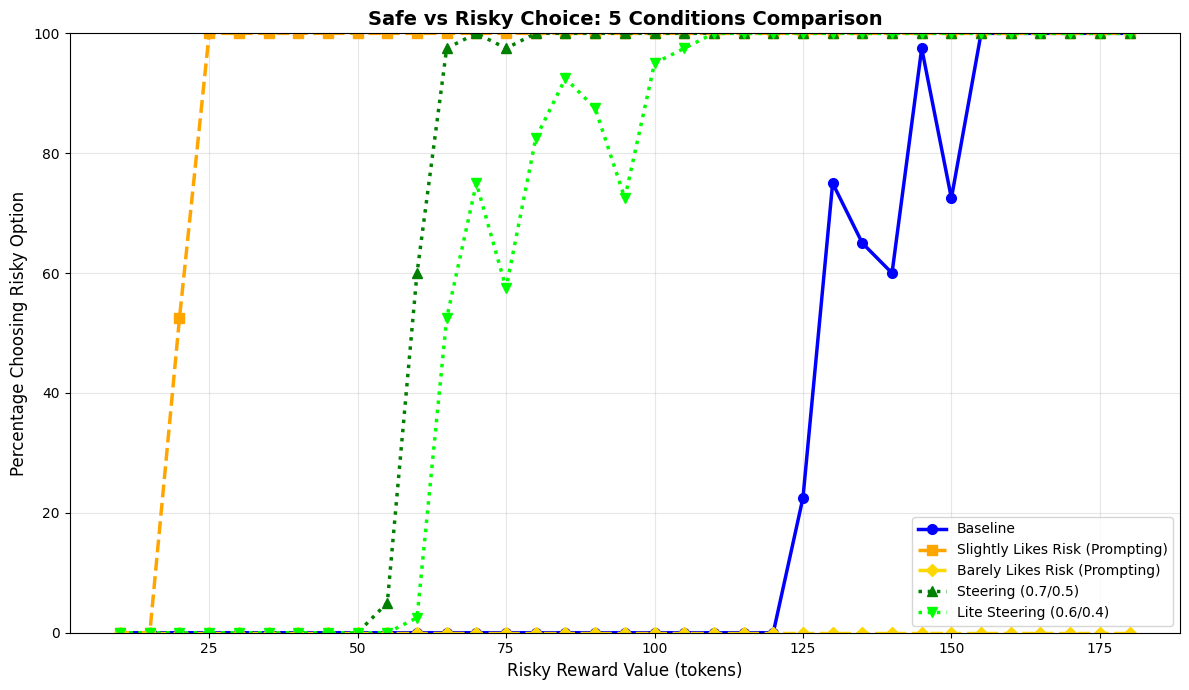

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_safe_risky_choices(directory=None):
    # If no directory specified, find the most recent results folder
    if directory is None:
        base_dir = "mech_interp_games/safe_risky_choice"
        if os.path.exists(base_dir):
            # Find all results directories with timestamps
            results_dirs = [d for d in os.listdir(base_dir) if d.startswith("results_")]
            if results_dirs:
                # Sort by timestamp (newest first)
                results_dirs.sort(reverse=True)
                directory = os.path.join(base_dir, results_dirs[0])
                print(f"Using most recent results directory: {directory}")
            else:
                print("No results directories found!")
                return
        else:
            print("Base directory not found!")
            return
    
    # Identify all relevant files
    files = sorted([f for f in os.listdir(directory) if f.startswith("safe_risky_") and f.endswith(".csv")])

    # Data storage for five conditions
    baseline_data = {}
    slightly_prompting_data = {}
    barely_prompting_data = {}
    steering_data = {}
    lite_steering_data = {}

    # Process each file
    for file in files:
        file_path = os.path.join(directory, file)
        df = pd.read_csv(file_path)
        
        # Compute percentage of "Risky Option"
        total_choices = len(df)
        risky_count = (df["answer.safe_risky_choice"] == "Risky Option").sum()
        risky_percentage = (risky_count / total_choices) * 100
        
        # Extract iteration number from filename
        iteration = int(file.split("_")[-1].split(".")[0])
        
        # Store in appropriate dictionary based on condition
        if "baseline" in file:
            baseline_data[iteration] = risky_percentage
        elif "slightly_prompting" in file:
            slightly_prompting_data[iteration] = risky_percentage
        elif "barely_prompting" in file:
            barely_prompting_data[iteration] = risky_percentage
        elif "lite_steering" in file:
            lite_steering_data[iteration] = risky_percentage
        elif "steering" in file:
            steering_data[iteration] = risky_percentage

    # Sort by iteration number
    baseline_data = dict(sorted(baseline_data.items()))
    slightly_prompting_data = dict(sorted(slightly_prompting_data.items()))
    barely_prompting_data = dict(sorted(barely_prompting_data.items()))
    steering_data = dict(sorted(steering_data.items()))
    lite_steering_data = dict(sorted(lite_steering_data.items()))

    # Create simple plot
    plt.figure(figsize=(12, 7))
    
    # Plot the five conditions
    plt.plot(baseline_data.keys(), baseline_data.values(), 
             marker="o", linestyle="-", linewidth=2.5, markersize=7,
             label="Baseline", color='blue')
    
    plt.plot(slightly_prompting_data.keys(), slightly_prompting_data.values(), 
             marker="s", linestyle="--", linewidth=2.5, markersize=7,
             label="Slightly Likes Risk (Prompting)", color='orange')
    
    plt.plot(barely_prompting_data.keys(), barely_prompting_data.values(), 
             marker="D", linestyle="--", linewidth=2.5, markersize=6,
             label="Barely Likes Risk (Prompting)", color='gold')
    
    plt.plot(steering_data.keys(), steering_data.values(), 
             marker="^", linestyle=":", linewidth=2.5, markersize=7,
             label="Steering (0.7/0.5)", color='green')
    
    plt.plot(lite_steering_data.keys(), lite_steering_data.values(), 
             marker="v", linestyle=":", linewidth=2.5, markersize=7,
             label="Lite Steering (0.6/0.4)", color='lime')

    plt.xlabel("Risky Reward Value (tokens)", fontsize=12)
    plt.ylabel("Percentage Choosing Risky Option", fontsize=12)
    plt.title("Safe vs Risky Choice: 5 Conditions Comparison", fontsize=14, fontweight='bold')
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 100)
    
    plt.tight_layout()
    plt.show()

# Example usage:
plot_safe_risky_choices()  # Automatically uses the most recent results directory


Using most recent results directory: mech_interp_games/safe_risky_choice/results_20251008_225522


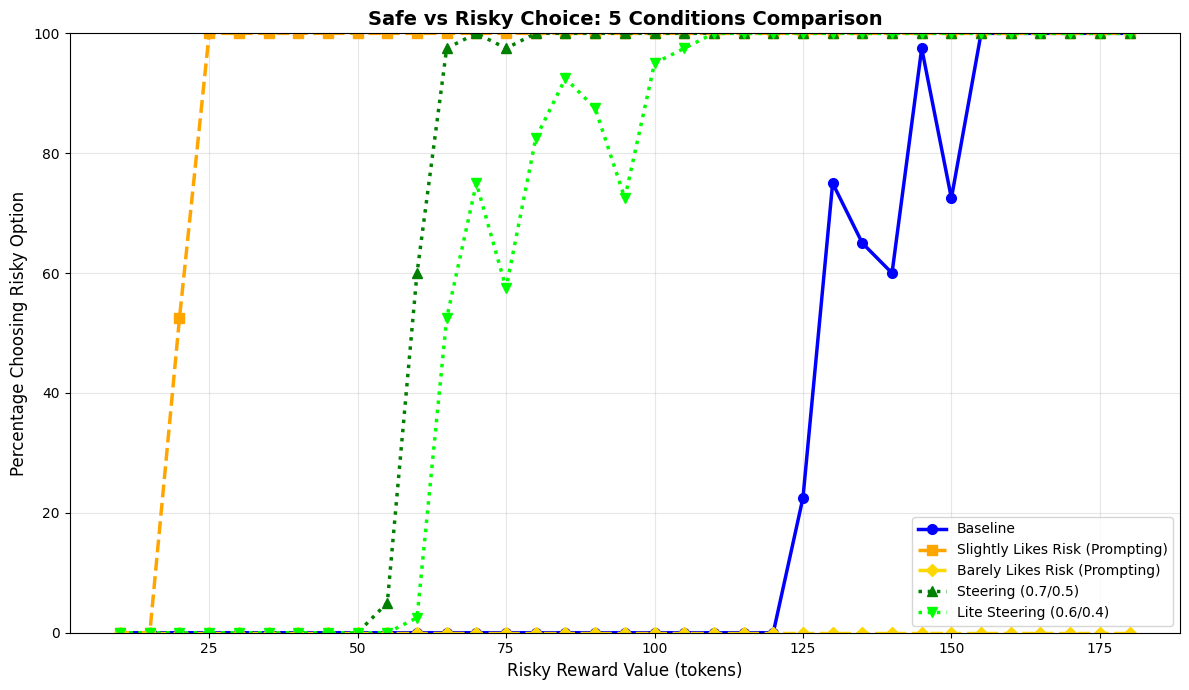

In [12]:
# Plot the results after running experiments
plot_safe_risky_choices()  # Automatically uses the most recent results directory


## LDA Topic Modeling on Agent Comments (Separate by Condition)

Perform Latent Dirichlet Allocation separately for each experimental condition to identify distinct reasoning patterns

In [4]:
import numpy as np
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import os

In [5]:
def load_comments_by_condition(directory=None):
    """Load agent comments organized by condition"""
    # If no directory specified, find the most recent results folder
    if directory is None:
        base_dir = "mech_interp_games/safe_risky_choice"
        if os.path.exists(base_dir):
            results_dirs = [d for d in os.listdir(base_dir) if d.startswith("results_")]
            if results_dirs:
                results_dirs.sort(reverse=True)
                directory = os.path.join(base_dir, results_dirs[0])
                print(f"Using most recent results directory: {directory}")
            else:
                print("No results directories found!")
                return None
        else:
            print("Base directory not found!")
            return None
    
    # Identify all CSV files
    files = sorted([f for f in os.listdir(directory) if f.startswith("safe_risky_") and f.endswith(".csv")])
    
    # Organize by condition
    comments_by_condition = defaultdict(list)
    metadata_by_condition = defaultdict(list)
    
    # Process each file
    for file in files:
        file_path = os.path.join(directory, file)
        df = pd.read_csv(file_path)
        
        # Extract condition and reward value from filename
        reward = int(file.split("_")[-1].split(".")[0])
        
        if "baseline" in file:
            condition = "Baseline"
        elif "slightly_prompting" in file:
            condition = "Slightly Risk Prompting"
        elif "barely_prompting" in file:
            condition = "Barely Risk Prompting"
        elif "lite_steering" in file:
            condition = "Lite Steering"
        elif "steering" in file:
            condition = "Steering"
        else:
            condition = "Unknown"
        
        # Extract comments
        comment_col = "comment.safe_risky_choice_comment"
        if comment_col in df.columns:
            for idx, comment in enumerate(df[comment_col]):
                if pd.notna(comment) and comment.strip():
                    comments_by_condition[condition].append(comment)
                    metadata_by_condition[condition].append({
                        'reward': reward,
                        'agent_idx': idx,
                        'choice': df.loc[idx, "answer.safe_risky_choice"] if "answer.safe_risky_choice" in df.columns else None
                    })
    
    print(f"\nComments loaded per condition:")
    for condition, comments in comments_by_condition.items():
        print(f"  {condition}: {len(comments)} comments")
    
    return dict(comments_by_condition), {k: pd.DataFrame(v) for k, v in metadata_by_condition.items()}

# Load comments organized by condition
comments_by_condition, metadata_by_condition = load_comments_by_condition()

Using most recent results directory: mech_interp_games/safe_risky_choice/results_20251008_225522

Comments loaded per condition:
  Barely Risk Prompting: 1400 comments
  Baseline: 1400 comments
  Lite Steering: 1400 comments
  Slightly Risk Prompting: 1400 comments
  Steering: 1400 comments


In [12]:
def perform_lda_by_condition(comments_by_condition, n_topics=10, n_top_words=10, max_features=500):
    """Perform LDA separately for each condition"""
    
    results = {}
    
    for condition, comments in comments_by_condition.items():
        print(f"\n{'='*80}")
        print(f"LDA ANALYSIS FOR: {condition.upper()}")
        print(f"{'='*80}")
        print(f"Number of comments: {len(comments)}")
        
        if len(comments) < 10:
            print(f"⚠️  Too few comments for meaningful LDA analysis")
            continue
        
        # Vectorize the comments
        vectorizer = CountVectorizer(
            max_features=max_features,
            stop_words='english',
            min_df=2,
            max_df=0.8,
            ngram_range=(1, 2)
        )
        
        try:
            doc_term_matrix = vectorizer.fit_transform(comments)
            feature_names = vectorizer.get_feature_names_out()
            
            print(f"Vocabulary size: {len(feature_names)}\n")
            
            # Fit LDA model
            lda_model = LatentDirichletAllocation(
                n_components=n_topics,
                random_state=42,
                max_iter=50,
                learning_method='batch',
                n_jobs=-1
            )
            
            doc_topics = lda_model.fit_transform(doc_term_matrix)
            
            # Display topics with top words
            topics_dict = {}
            for topic_idx, topic in enumerate(lda_model.components_):
                top_words_idx = topic.argsort()[-n_top_words:][::-1]
                top_words = [feature_names[i] for i in top_words_idx]
                top_weights = [topic[i] for i in top_words_idx]
                
                topics_dict[f"Topic {topic_idx + 1}"] = top_words
                
                print(f"Topic {topic_idx + 1}:")
                print(f"  Keywords: {', '.join(top_words[:7])}")
                print()
            
            results[condition] = {
                'lda_model': lda_model,
                'vectorizer': vectorizer,
                'doc_topics': doc_topics,
                'doc_term_matrix': doc_term_matrix,
                'topics_dict': topics_dict,
                'feature_names': feature_names
            }
            
        except Exception as e:
            print(f"⚠️  Error performing LDA: {e}")
            continue
    
    return results

# Perform LDA separately for each condition (using 3 topics per condition)
lda_results_by_condition = perform_lda_by_condition(comments_by_condition, n_topics=10, n_top_words=10)



LDA ANALYSIS FOR: BARELY RISK PROMPTING
Number of comments: 1400
Vocabulary size: 76

Topic 1:
  Keywords: guaranteed, outcome, provides, option provides, provides guaranteed, guaranteed outcome, uncertainty

Topic 2:
  Keywords: guarantees 50, thing risky, tokens sure, sure, sure thing, thing, uncertain

Topic 3:
  Keywords: guarantees 50, uncertain, tolerance, risk tolerance, risk, uncertain risk, tokens uncertain

Topic 4:
  Keywords: guarantees 50, chance leaving, leaving, leaving tokens, tokens worth, potential loss, worth

Topic 5:
  Keywords: getting, possibility getting, possibility, getting tokens, appealing possibility, risks guarantee, guarantee

Topic 6:
  Keywords: potential, reward, chose safe, appealing, higher, potential reward, risks guarantee

Topic 7:
  Keywords: risks guaranteed, guaranteed 50, chose safe, certain outcome, tokens provides, provides certain, certain

Topic 8:
  Keywords: risk, uncertain risk, tokens uncertain, uncertain, guarantees 50, tolerance, ri

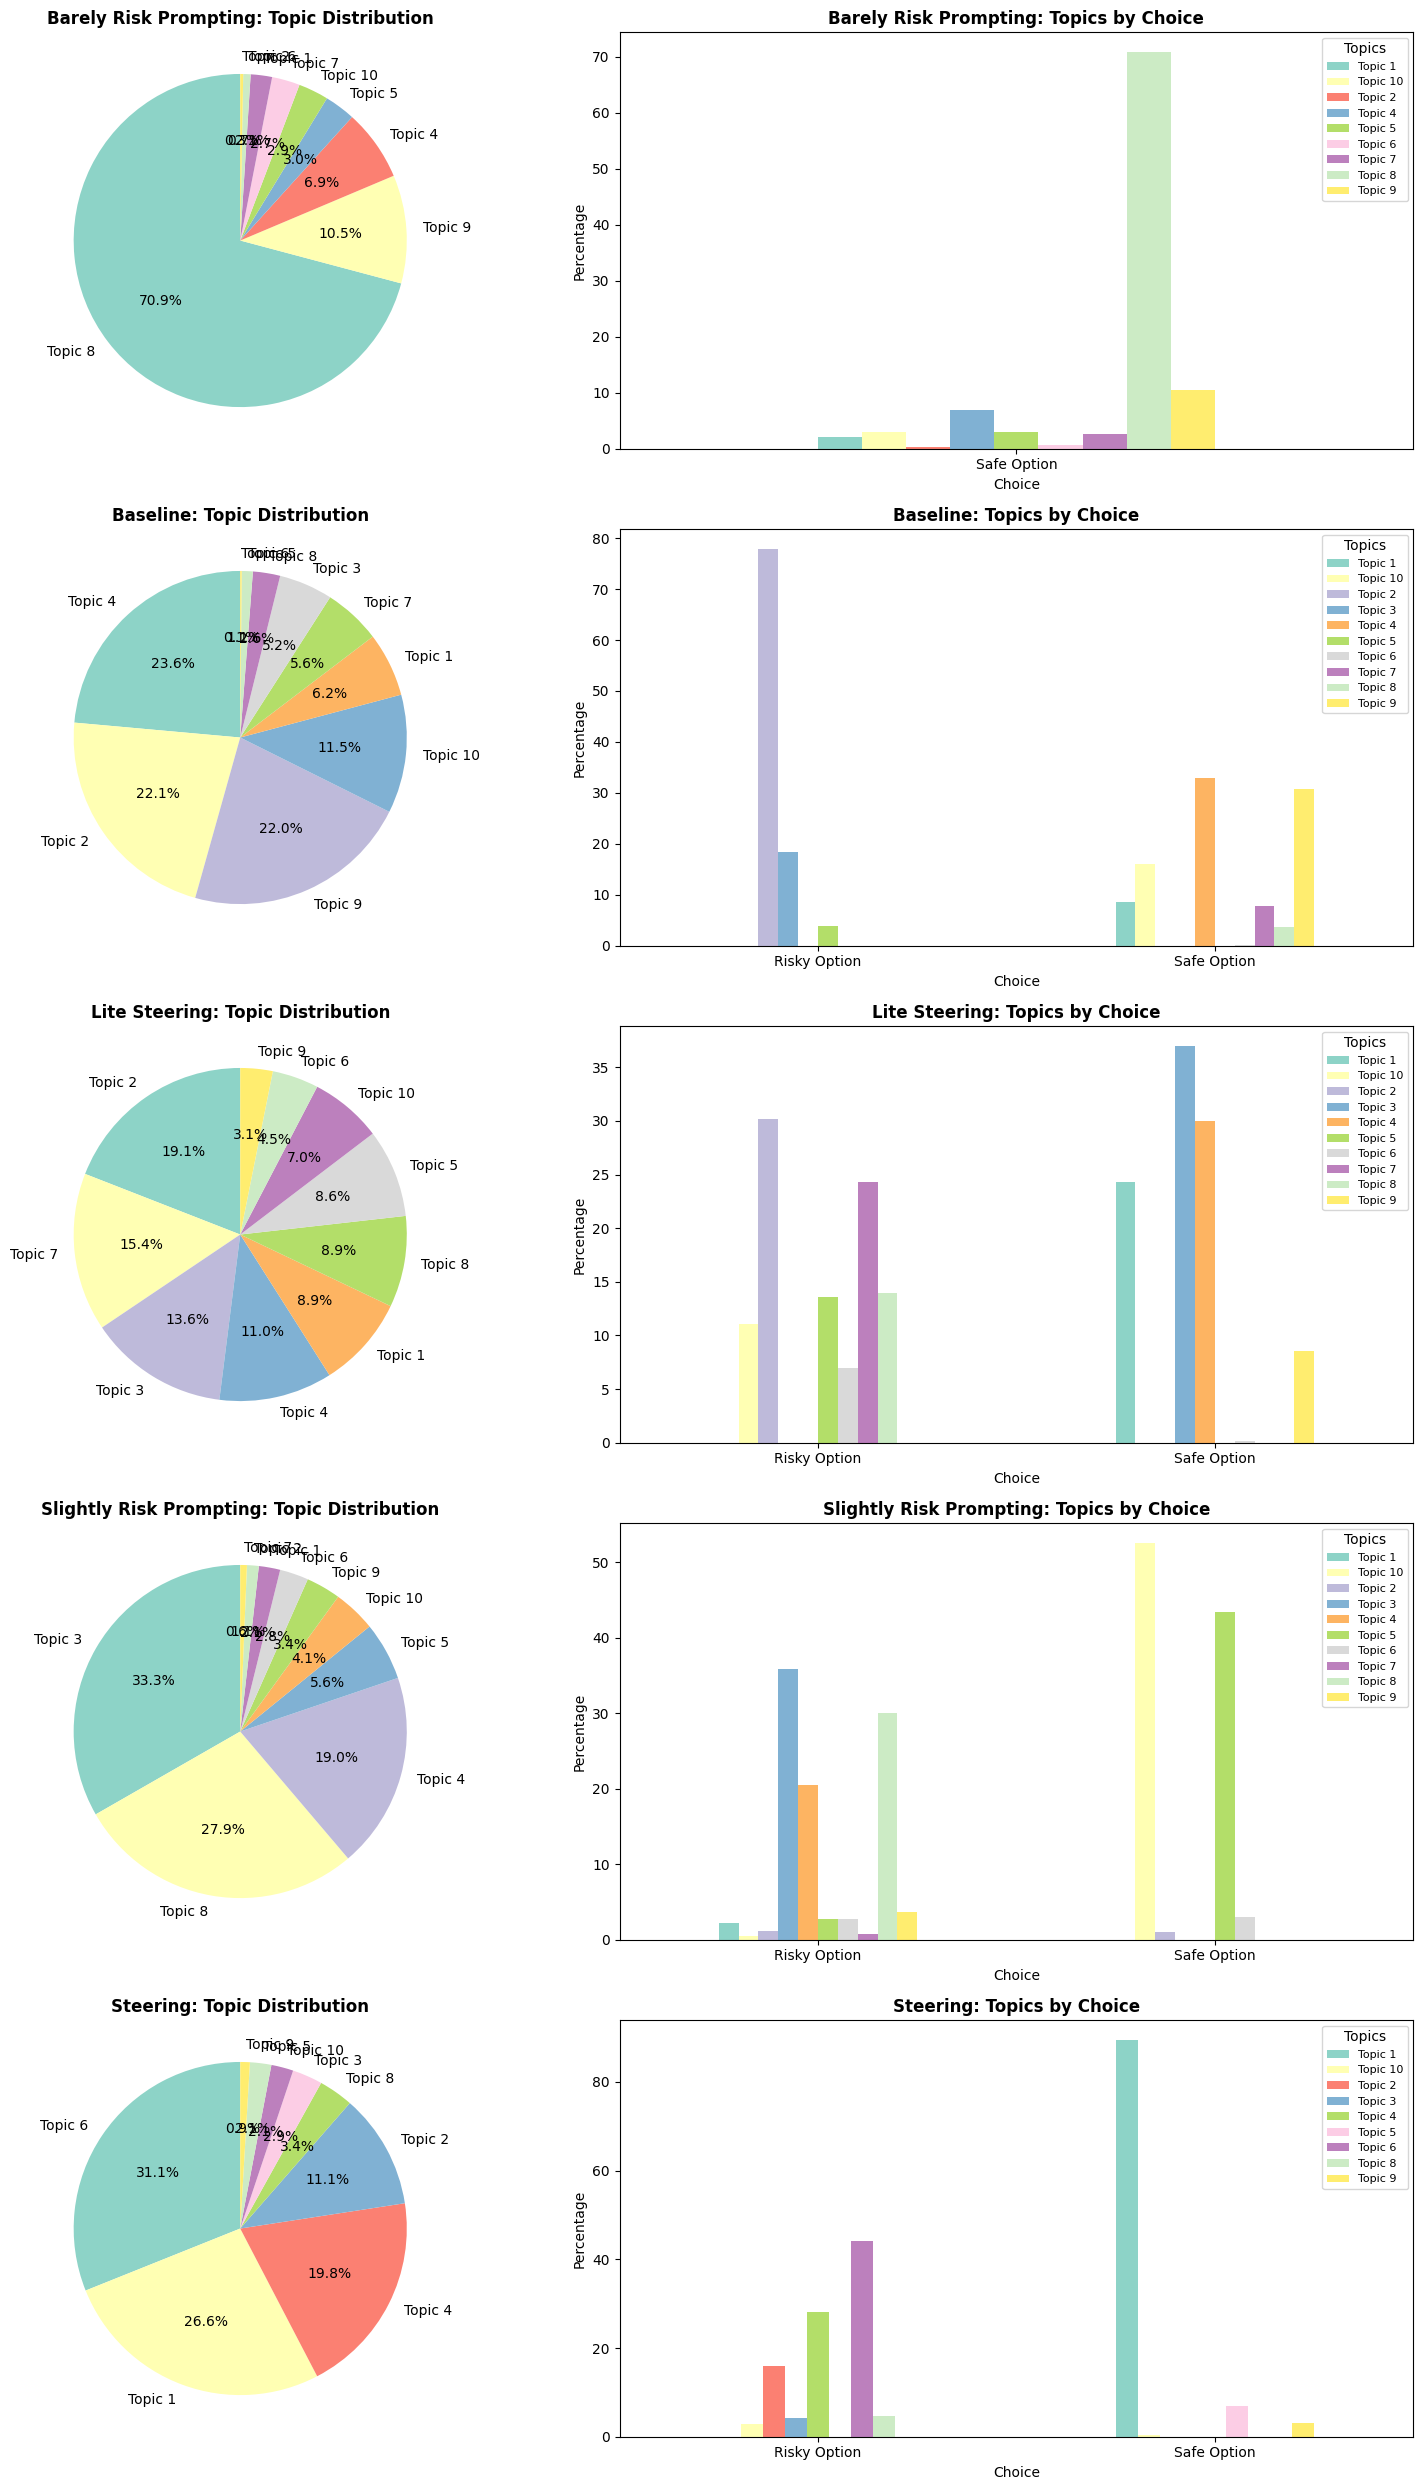

In [13]:
def visualize_topics_by_condition(lda_results_by_condition, comments_by_condition, metadata_by_condition):
    """Create comprehensive visualizations for each condition"""
    
    n_conditions = len(lda_results_by_condition)
    
    # Create a large figure with subplots for each condition
    fig, axes = plt.subplots(n_conditions, 2, figsize=(16, 5 * n_conditions))
    
    if n_conditions == 1:
        axes = axes.reshape(1, -1)
    
    for idx, (condition, results) in enumerate(lda_results_by_condition.items()):
        doc_topics = results['doc_topics']
        metadata_df = metadata_by_condition[condition].copy()
        
        # Add dominant topic to metadata
        dominant_topic = np.argmax(doc_topics, axis=1)
        metadata_df['dominant_topic'] = [f"Topic {t+1}" for t in dominant_topic]
        
        # 1. Topic distribution (pie chart)
        ax1 = axes[idx, 0]
        topic_counts = metadata_df['dominant_topic'].value_counts()
        colors = plt.cm.Set3(np.linspace(0, 1, len(topic_counts)))
        ax1.pie(topic_counts.values, labels=topic_counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
        ax1.set_title(f'{condition}: Topic Distribution', fontsize=12, fontweight='bold')
        
        # 2. Topic distribution by choice
        ax2 = axes[idx, 1]
        if 'choice' in metadata_df.columns:
            topic_by_choice = pd.crosstab(
                metadata_df['choice'],
                metadata_df['dominant_topic'],
                normalize='index'
            ) * 100
            
            topic_by_choice.plot(kind='bar', ax=ax2, colormap='Set3')
            ax2.set_title(f'{condition}: Topics by Choice', fontsize=12, fontweight='bold')
            ax2.set_xlabel('Choice', fontsize=10)
            ax2.set_ylabel('Percentage', fontsize=10)
            ax2.legend(title='Topics', fontsize=8)
            ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
        else:
            ax2.text(0.5, 0.5, 'No choice data available', 
                    ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title(f'{condition}: Topics by Choice', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Visualize topics for each condition
visualize_topics_by_condition(lda_results_by_condition, comments_by_condition, metadata_by_condition)


In [14]:
def show_detailed_topics_by_condition(lda_results_by_condition, n_top_words=15):
    """Show detailed topic information for each condition"""
    
    print(f"\n{'='*100}")
    print(f"DETAILED TOPIC ANALYSIS BY CONDITION")
    print(f"{'='*100}\n")
    
    for condition, results in lda_results_by_condition.items():
        print(f"\n{'='*100}")
        print(f"{condition.upper()}")
        print(f"{'='*100}\n")
        
        lda_model = results['lda_model']
        feature_names = results['feature_names']
        
        for topic_idx, topic in enumerate(lda_model.components_):
            top_words_idx = topic.argsort()[-n_top_words:][::-1]
            top_words = [feature_names[i] for i in top_words_idx]
            top_weights = [topic[i] for i in top_words_idx]
            
            print(f"Topic {topic_idx + 1}:")
            for word, weight in zip(top_words, top_weights):
                print(f"  {word:30s} {weight:8.4f}")
            print()

# Show detailed topics
show_detailed_topics_by_condition(lda_results_by_condition, n_top_words=15)



DETAILED TOPIC ANALYSIS BY CONDITION


BARELY RISK PROMPTING

Topic 1:
  guaranteed                      30.9773
  outcome                         29.2864
  provides                        28.8933
  option provides                 27.1003
  provides guaranteed             27.1003
  guaranteed outcome              27.1000
  uncertainty                     20.1000
  outcome appealing               16.1000
  appealing                       16.1000
  uncertainty risky               16.1000
  appealing uncertainty           16.1000
  outcome risky                   12.2825
  unappealing uncertainty          4.1000
  unappealing                      4.1000
  tokens unappealing               4.1000

Topic 2:
  guarantees 50                    4.1042
  thing risky                      4.1000
  tokens sure                      4.1000
  sure                             4.1000
  sure thing                       4.1000
  thing                            4.1000
  uncertain                        0

In [15]:
def show_example_comments_by_condition(lda_results_by_condition, comments_by_condition, n_examples=2):
    """Show example comments for each topic within each condition"""
    
    print(f"\n{'='*100}")
    print(f"EXAMPLE COMMENTS BY CONDITION AND TOPIC")
    print(f"{'='*100}\n")
    
    for condition, results in lda_results_by_condition.items():
        print(f"\n{'#'*100}")
        print(f"# {condition.upper()}")
        print(f"{'#'*100}\n")
        
        doc_topics = results['doc_topics']
        comments = comments_by_condition[condition]
        dominant_topics = np.argmax(doc_topics, axis=1)
        
        for topic_idx in range(doc_topics.shape[1]):
            print(f"\nTopic {topic_idx + 1}:")
            print(f"{'-'*80}")
            
            # Find documents strongly associated with this topic
            topic_docs = np.where(dominant_topics == topic_idx)[0]
            
            if len(topic_docs) > 0:
                # Get the top examples
                topic_probs = doc_topics[topic_docs, topic_idx]
                top_examples_idx = topic_docs[np.argsort(topic_probs)[-n_examples:][::-1]]
                
                for i, doc_idx in enumerate(top_examples_idx, 1):
                    prob = doc_topics[doc_idx, topic_idx]
                    comment = comments[doc_idx]
                    
                    # Truncate long comments
                    if len(comment) > 250:
                        comment = comment[:250] + "..."
                    
                    print(f"\nExample {i} (prob: {prob:.3f}):")
                    print(f"{comment}")
            else:
                print("  No strong examples for this topic")
        
        print()

# Show example comments for each condition
show_example_comments_by_condition(lda_results_by_condition, comments_by_condition, n_examples=2)



EXAMPLE COMMENTS BY CONDITION AND TOPIC


####################################################################################################
# BARELY RISK PROMPTING
####################################################################################################


Topic 1:
--------------------------------------------------------------------------------

Example 1 (prob: 0.925):
I chose this option because I barely like to take risks, and the safe option provides a guaranteed outcome, which is more appealing to me than the uncertainty of the risky option.

Example 2 (prob: 0.925):
I chose this option because I barely like to take risks, and the safe option provides a guaranteed outcome, which is more appealing to me than the uncertainty of the risky option.

Topic 2:
--------------------------------------------------------------------------------

Example 1 (prob: 0.871):
I chose this option because I barely like to take risks, and the safe option guarantees me 50 tokens, which is

In [16]:
def compare_topic_choices(lda_results_by_condition, metadata_by_condition):
    """Compare how topics relate to choices across conditions"""
    
    print(f"\n{'='*100}")
    print(f"TOPIC-CHOICE RELATIONSHIP BY CONDITION")
    print(f"{'='*100}\n")
    
    for condition, results in lda_results_by_condition.items():
        print(f"\n{condition}:")
        print(f"{'-'*80}")
        
        doc_topics = results['doc_topics']
        metadata_df = metadata_by_condition[condition].copy()
        
        # Add dominant topic
        dominant_topic = np.argmax(doc_topics, axis=1)
        metadata_df['dominant_topic'] = [f"Topic {t+1}" for t in dominant_topic]
        
        if 'choice' in metadata_df.columns:
            # Calculate choice percentages for each topic
            for topic_num in range(doc_topics.shape[1]):
                topic_name = f"Topic {topic_num + 1}"
                topic_data = metadata_df[metadata_df['dominant_topic'] == topic_name]
                
                if len(topic_data) > 0:
                    choice_dist = topic_data['choice'].value_counts(normalize=True) * 100
                    print(f"\n  {topic_name} ({len(topic_data)} comments):")
                    for choice, pct in choice_dist.items():
                        print(f"    {choice}: {pct:.1f}%")
        else:
            print("  No choice data available")
    
    print(f"\n{'='*100}\n")

# Compare topics and choices
compare_topic_choices(lda_results_by_condition, metadata_by_condition)



TOPIC-CHOICE RELATIONSHIP BY CONDITION


Barely Risk Prompting:
--------------------------------------------------------------------------------

  Topic 1 (29 comments):
    Safe Option: 100.0%

  Topic 2 (4 comments):
    Safe Option: 100.0%

  Topic 4 (97 comments):
    Safe Option: 100.0%

  Topic 5 (42 comments):
    Safe Option: 100.0%

  Topic 6 (10 comments):
    Safe Option: 100.0%

  Topic 7 (38 comments):
    Safe Option: 100.0%

  Topic 8 (992 comments):
    Safe Option: 100.0%

  Topic 9 (147 comments):
    Safe Option: 100.0%

  Topic 10 (41 comments):
    Safe Option: 100.0%

Baseline:
--------------------------------------------------------------------------------

  Topic 1 (87 comments):
    Safe Option: 100.0%

  Topic 2 (309 comments):
    Risky Option: 100.0%

  Topic 3 (73 comments):
    Risky Option: 100.0%

  Topic 4 (330 comments):
    Safe Option: 100.0%

  Topic 5 (15 comments):
    Risky Option: 100.0%

  Topic 6 (2 comments):
    Safe Option: 100.0%

  Top

In [17]:
def save_lda_results_by_condition(lda_results_by_condition, comments_by_condition, 
                                   metadata_by_condition, directory=None):
    """Save LDA results for each condition to files"""
    
    if directory is None:
        base_dir = "mech_interp_games/safe_risky_choice"
        results_dirs = [d for d in os.listdir(base_dir) if d.startswith("results_")]
        if results_dirs:
            results_dirs.sort(reverse=True)
            directory = os.path.join(base_dir, results_dirs[0])
    
    # Save comprehensive topics report
    topics_file = os.path.join(directory, "lda_topics_by_condition.txt")
    with open(topics_file, 'w', encoding='utf-8') as f:
        f.write("LDA TOPIC MODELING RESULTS BY CONDITION\n")
        f.write("=" * 100 + "\n\n")
        
        for condition, results in lda_results_by_condition.items():
            f.write(f"\n{'='*100}\n")
            f.write(f"{condition.upper()}\n")
            f.write(f"{'='*100}\n\n")
            
            lda_model = results['lda_model']
            feature_names = results['feature_names']
            topics_dict = results['topics_dict']
            
            for topic_name, words in topics_dict.items():
                f.write(f"{topic_name}:\n")
                f.write(f"  {', '.join(words)}\n\n")
    
    # Save individual CSV files for each condition
    for condition, results in lda_results_by_condition.items():
        doc_topics = results['doc_topics']
        metadata_df = metadata_by_condition[condition].copy()
        
        # Add topic information
        dominant_topic = np.argmax(doc_topics, axis=1)
        metadata_df['dominant_topic'] = [f"Topic {t+1}" for t in dominant_topic]
        
        # Add topic probabilities
        for i in range(doc_topics.shape[1]):
            metadata_df[f'topic_{i+1}_prob'] = doc_topics[:, i]
        
        # Add comments
        metadata_df['comment'] = comments_by_condition[condition]
        
        # Save to CSV
        condition_safe = condition.replace(" ", "_").lower()
        csv_file = os.path.join(directory, f"lda_analysis_{condition_safe}.csv")
        metadata_df.to_csv(csv_file, index=False)
        print(f"✓ Saved: {csv_file}")
    
    print(f"\n✓ LDA topics report saved to: {topics_file}")

# Save all results
save_lda_results_by_condition(lda_results_by_condition, comments_by_condition, metadata_by_condition)


✓ Saved: mech_interp_games/safe_risky_choice/results_20251008_225522/lda_analysis_barely_risk_prompting.csv
✓ Saved: mech_interp_games/safe_risky_choice/results_20251008_225522/lda_analysis_baseline.csv
✓ Saved: mech_interp_games/safe_risky_choice/results_20251008_225522/lda_analysis_lite_steering.csv
✓ Saved: mech_interp_games/safe_risky_choice/results_20251008_225522/lda_analysis_slightly_risk_prompting.csv
✓ Saved: mech_interp_games/safe_risky_choice/results_20251008_225522/lda_analysis_steering.csv

✓ LDA topics report saved to: mech_interp_games/safe_risky_choice/results_20251008_225522/lda_topics_by_condition.txt
